# 02 - A small learning-rate search

Sweep a handful of learning rates for one architecture and compare final
validation loss. The same pattern extends to any hyperparameter.

In [1]:
import sys
sys.path.append('..')

import torch
import matplotlib.pyplot as plt
from flashdet import engine
from flashdet.data import make_train_val_loaders
from flashdet.models import build_model
from flashdet.utils import build_optimizer, build_scheduler, set_seed

device = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_PATH = 'demo_dataset.npy'

## Sweep
Re-seed before each run so models differ only by learning rate.

In [2]:
learning_rates = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
final_val_loss = []

for lr in learning_rates:
    set_seed(42)
    train_loader, val_loader, _ = make_train_val_loaders(DATA_PATH, batch_size=5, val_ratio=0.2)
    model = build_model('conformer', d_model=32, num_heads=4, num_layers=2).to(device)
    opt = build_optimizer(model, {'lr': lr})
    sch = build_scheduler(opt, {})
    results = engine.train(model, train_loader, val_loader, opt, sch,
                           device=device, epochs=5, val_every=5, save_every=99)
    val = results['eval_loss'][-1] if results['eval_loss'] else float('nan')
    final_val_loss.append(val)
    print(f'lr={lr:.0e}  val_loss={val:.4f}')

Epoch 1/5:   0%|          | 0/32 [00:00<?, ?it/s]/sdf/home/c/carsmith/flash_reconstruction/flash_detection/examples/../flashdet/data.py:117: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  /opt/conda/conda-bld/pytorch_1634272068694/work/torch/csrc/utils/tensor_new.cpp:201.)
  hit_times = torch.tensor([item[2] for item in batch])


lr=1e-05  val_loss=1.4448


lr=3e-05  val_loss=1.4601


lr=1e-04  val_loss=0.9125


lr=3e-04  val_loss=0.3579


lr=1e-03  val_loss=0.1322


## Plot val loss vs learning rate

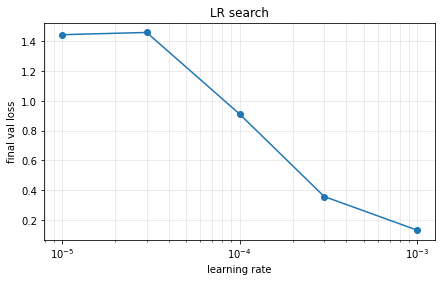

best learning rate: 0.001


In [3]:
plt.figure(figsize=(7, 4))
plt.plot(learning_rates, final_val_loss, 'o-')
plt.xscale('log')
plt.xlabel('learning rate'); plt.ylabel('final val loss')
plt.title('LR search'); plt.grid(True, which='both', alpha=0.3)
plt.show()

best = learning_rates[int(min(range(len(final_val_loss)), key=lambda i: final_val_loss[i]))]
print('best learning rate:', best)